# Lista 4 - Redes Neurais Artificiais

**Disciplina:** CKP8277 - Aprendizagem Automatica | **Periodo:** 2026.1
**Professor:** Cesar Lincoln Cavalcante Mattos
**Aluno:** Diego Melo do Nascimento | **Matricula:** 603127

- Questao 1: MLP para regressao (`concrete.csv`)
- Questao 2: MLP para classificacao (`vehicle.csv`)

A MLP e o backpropagation sao implementados do zero. Os hiperparametros sao
ajustados por busca aleatoria, selecionando a configuracao de melhor desempenho
no conjunto de **validacao**, conforme o enunciado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Funcoes auxiliares

In [2]:
def split_data(X, y, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    a, b = int(0.6 * len(X)), int(0.8 * len(X))
    return (X[idx[:a]], y[idx[:a]], X[idx[a:b]], y[idx[a:b]], X[idx[b:]], y[idx[b:]])

def standardize_fit(X):
    mu, sigma = X.mean(0), X.std(0)
    sigma[sigma == 0] = 1
    return mu, sigma

def standardize(X, mu, sigma):
    return (X - mu) / sigma

def one_hot(y, k):
    Y = np.zeros((len(y), k))
    Y[np.arange(len(y)), y.astype(int)] = 1
    return Y

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    e = np.exp(z - z.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

In [3]:
def rmse(y, p):
    return np.sqrt(np.mean((y - p) ** 2))

def mae(y, p):
    return np.mean(np.abs(y - p))

def mre(y, p):
    return np.mean(np.abs((y - p) / y))

def accuracy(y, p):
    return np.mean(y == p)

def confusion_matrix(y, p, k):
    cm = np.zeros((k, k), dtype=int)
    for t, q in zip(y.astype(int), p.astype(int)):
        cm[t, q] += 1
    return cm

def macro_prf(y, p, k):
    cm = confusion_matrix(y, p, k)
    prec, rec, f1 = [], [], []
    for i in range(k):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        pr = tp / (tp + fp) if tp + fp else 0.0
        rc = tp / (tp + fn) if tp + fn else 0.0
        prec.append(pr)
        rec.append(rc)
        f1.append(2 * pr * rc / (pr + rc) if pr + rc else 0.0)
    return np.mean(prec), np.mean(rec), np.mean(f1)

## Implementacao da MLP

Uma camada oculta com ReLU, treinada em mini-batch via SGD com momentum. O bias e
embutido na coluna 0 das matrizes de peso (`W` na camada oculta, `M` na saida). A
saida e linear na regressao e softmax na classificacao.

In [4]:
class MLP:
    def __init__(self, n_in, n_hidden, n_out, task='reg',
                 lr=0.01, momentum=0.9, batch_size=32, epochs=300, seed=42):
        self.task = task
        self.lr = lr
        self.momentum = momentum
        self.batch_size = batch_size
        self.epochs = epochs
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, np.sqrt(2 / n_in), (n_hidden, n_in + 1))
        self.M = rng.normal(0, np.sqrt(2 / n_hidden), (n_out, n_hidden + 1))
        self.W[:, 0] = 0
        self.M[:, 0] = 0
        self.vW = np.zeros_like(self.W)
        self.vM = np.zeros_like(self.M)

    @staticmethod
    def _bias(X):
        return np.hstack([np.ones((len(X), 1)), X])

    def forward(self, X):
        self.Xa = self._bias(X)
        self.U = self.Xa @ self.W.T
        self.Za = self._bias(relu(self.U))
        R = self.Za @ self.M.T
        self.O = softmax(R) if self.task == 'clf' else R
        return self.O

    def backward(self, Y):
        delta = (self.O - Y) / len(Y)
        zeta = (self.U > 0) * (delta @ self.M[:, 1:])
        gW = zeta.T @ self.Xa
        gM = delta.T @ self.Za
        np.clip(gW, -5, 5, out=gW)
        np.clip(gM, -5, 5, out=gM)
        return gW, gM

    def _update(self, gW, gM):
        self.vW = self.momentum * self.vW - self.lr * gW
        self.vM = self.momentum * self.vM - self.lr * gM
        self.W += self.vW
        self.M += self.vM

    def _loss(self, Y):
        if self.task == 'clf':
            return float(-np.mean(np.sum(Y * np.log(self.O + 1e-9), axis=1)))
        return float(np.mean((Y - self.O) ** 2))

    def fit(self, X, Y, Xval, Yval):
        hist = {'train': [], 'val': []}
        for _ in range(self.epochs):
            order = np.random.permutation(len(X))
            for i in range(0, len(X), self.batch_size):
                b = order[i:i + self.batch_size]
                self.forward(X[b])
                self._update(*self.backward(Y[b]))
            self.forward(X)
            hist['train'].append(self._loss(Y))
            self.forward(Xval)
            hist['val'].append(self._loss(Yval))
        return hist

    def predict(self, X):
        O = self.forward(X)
        return O.argmax(1) if self.task == 'clf' else O.ravel()

A busca aleatoria treina cada configuracao no treino e a avalia na **validacao**.
Retorna um DataFrame ordenado pela metrica de validacao.

In [5]:
def random_search(build, eval_val, space, n_iter=40, maximize=False, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_iter):
        hp = {k: sampler(rng) for k, sampler in space.items()}
        rows.append({**hp, 'val_score': eval_val(build(hp))})
    return pd.DataFrame(rows).sort_values('val_score', ascending=not maximize,
                                          ignore_index=True)

space = {
    'n_hidden': lambda r: int(r.choice([16, 32, 64, 128])),
    'lr': lambda r: float(10 ** r.uniform(-3, -1)),
    'momentum': lambda r: float(r.choice([0.9, 0.95, 0.99])),
    'batch_size': lambda r: int(r.choice([16, 32, 64])),
}

## Questao 1 - Regressao (concrete.csv)

Resistencia a compressao do concreto (MPa) a partir de 8 atributos.

In [6]:
data = np.genfromtxt('data/concrete.csv', delimiter=',')
Xr, yr = data[:, :-1], data[:, -1]

Xr_tr, yr_tr, Xr_va, yr_va, Xr_te, yr_te = split_data(Xr, yr)
mu, sigma = standardize_fit(Xr_tr)
Xr_tr, Xr_va, Xr_te = (standardize(Xr_tr, mu, sigma),
                       standardize(Xr_va, mu, sigma),
                       standardize(Xr_te, mu, sigma))
print(f'treino {len(Xr_tr)} | validacao {len(Xr_va)} | teste {len(Xr_te)}')

treino 618 | validacao 206 | teste 206


### a) Ajuste dos hiperparametros na validacao

In [7]:
def build_reg(hp):
    m = MLP(Xr_tr.shape[1], hp['n_hidden'], 1, task='reg',
            lr=hp['lr'], momentum=hp['momentum'], batch_size=hp['batch_size'], epochs=200)
    m.fit(Xr_tr, yr_tr.reshape(-1, 1), Xr_va, yr_va.reshape(-1, 1))
    return m

res_r = random_search(build_reg, lambda m: rmse(yr_va, m.predict(Xr_va)),
                      space, n_iter=40, maximize=False)
res_r.head()

,n_hidden,lr,momentum,batch_size,val_score
0,128,0.001819,0.9,64,5.416991
1,128,0.001034,0.9,64,5.483064
2,128,0.003865,0.9,32,5.518338
3,64,0.001904,0.9,16,5.745839
4,32,0.005507,0.9,32,5.903942


### b) Treino final, curvas de custo e metricas

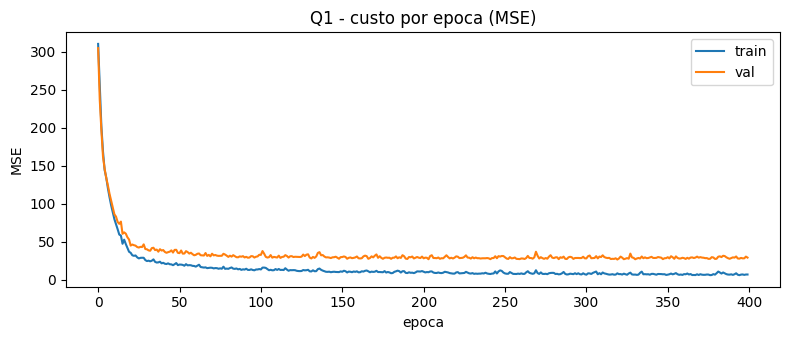

In [8]:
best = res_r.iloc[0]
mlp_r = MLP(Xr_tr.shape[1], int(best.n_hidden), 1, task='reg', lr=float(best.lr),
            momentum=float(best.momentum), batch_size=int(best.batch_size), epochs=400)
hist = mlp_r.fit(Xr_tr, yr_tr.reshape(-1, 1), Xr_va, yr_va.reshape(-1, 1))

pd.DataFrame(hist).plot(figsize=(8, 3.5), title='Q1 - custo por epoca (MSE)',
                        xlabel='epoca', ylabel='MSE')
plt.tight_layout()
plt.show()

In [9]:
pd.DataFrame({
    nome: {'RMSE': rmse(y, mlp_r.predict(X)),
           'MAE': mae(y, mlp_r.predict(X)),
           'MRE': mre(y, mlp_r.predict(X))}
    for nome, X, y in [('treino', Xr_tr, yr_tr),
                       ('validacao', Xr_va, yr_va),
                       ('teste', Xr_te, yr_te)]
}).T.round(4)

,RMSE,MAE,MRE
treino,2.5807,1.9440,0.0713
validacao,5.3802,3.8647,0.1203
teste,5.4905,3.9354,0.1376


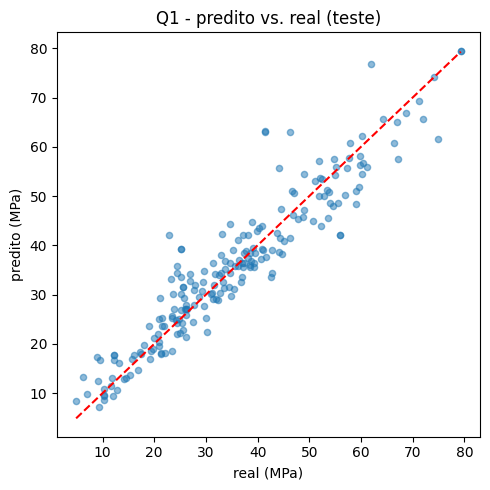

In [10]:
pred = mlp_r.predict(Xr_te)
plt.figure(figsize=(5, 5))
plt.scatter(yr_te, pred, alpha=0.5, s=20)
lim = [yr_te.min(), yr_te.max()]
plt.plot(lim, lim, 'r--')
plt.xlabel('real (MPa)')
plt.ylabel('predito (MPa)')
plt.title('Q1 - predito vs. real (teste)')
plt.tight_layout()
plt.show()

## Questao 2 - Classificacao (vehicle.csv)

Silhuetas de veiculos em 4 classes (bus, opel, saab, van) a partir de 18 atributos.

In [11]:
data = np.genfromtxt('data/vehicle.csv', delimiter=',')
Xc, yc = data[:, :-1], data[:, -1].astype(int)
CLASSES = ['bus', 'opel', 'saab', 'van']
K = 4

Xc_tr, yc_tr, Xc_va, yc_va, Xc_te, yc_te = split_data(Xc, yc)
mu, sigma = standardize_fit(Xc_tr)
Xc_tr, Xc_va, Xc_te = (standardize(Xc_tr, mu, sigma),
                       standardize(Xc_va, mu, sigma),
                       standardize(Xc_te, mu, sigma))
print(f'treino {len(Xc_tr)} | validacao {len(Xc_va)} | teste {len(Xc_te)}')

treino 507 | validacao 169 | teste 170


### a) Ajuste dos hiperparametros na validacao

In [12]:
Yc_tr = one_hot(yc_tr, K)

def build_clf(hp):
    m = MLP(Xc_tr.shape[1], hp['n_hidden'], K, task='clf',
            lr=hp['lr'], momentum=hp['momentum'], batch_size=hp['batch_size'], epochs=200)
    m.fit(Xc_tr, Yc_tr, Xc_va, one_hot(yc_va, K))
    return m

res_c = random_search(build_clf, lambda m: accuracy(yc_va, m.predict(Xc_va)),
                      space, n_iter=40, maximize=True)
res_c.head()

,n_hidden,lr,momentum,batch_size,val_score
0,64,0.033884,0.95,32,0.881657
1,16,0.027843,0.90,64,0.881657
2,128,0.008579,0.90,32,0.869822
3,16,0.045213,0.90,32,0.863905
4,64,0.004214,0.99,64,0.863905


### b) Treino final, curvas de custo, metricas e matriz de confusao

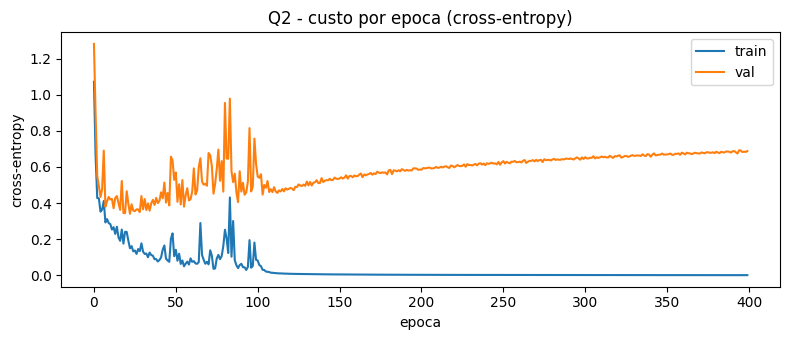

In [13]:
best = res_c.iloc[0]
mlp_c = MLP(Xc_tr.shape[1], int(best.n_hidden), K, task='clf', lr=float(best.lr),
            momentum=float(best.momentum), batch_size=int(best.batch_size), epochs=400)
hist = mlp_c.fit(Xc_tr, Yc_tr, Xc_va, one_hot(yc_va, K))

pd.DataFrame(hist).plot(figsize=(8, 3.5), title='Q2 - custo por epoca (cross-entropy)',
                        xlabel='epoca', ylabel='cross-entropy')
plt.tight_layout()
plt.show()

In [14]:
rows = {}
for nome, X, y in [('treino', Xc_tr, yc_tr), ('validacao', Xc_va, yc_va), ('teste', Xc_te, yc_te)]:
    p = mlp_c.predict(X)
    prec, rec, f1 = macro_prf(y, p, K)
    rows[nome] = {'acuracia': accuracy(y, p), 'precisao': prec, 'revocacao': rec, 'f1': f1}
pd.DataFrame(rows).T.round(4)

,acuracia,precisao,revocacao,f1
treino,1.0000,1.0000,1.0000,1.0000
validacao,0.8757,0.8819,0.8911,0.8853
teste,0.7471,0.7574,0.7537,0.7440


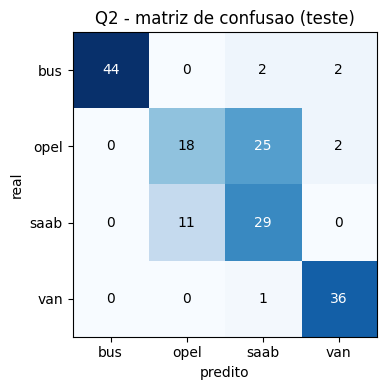

In [15]:
cm = confusion_matrix(yc_te, mlp_c.predict(Xc_te), K)
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap='Blues')
for i in range(K):
    for j in range(K):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.xticks(range(K), CLASSES)
plt.yticks(range(K), CLASSES)
plt.xlabel('predito')
plt.ylabel('real')
plt.title('Q2 - matriz de confusao (teste)')
plt.tight_layout()
plt.show()